In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
# %matplotlib widget

Burgers equation
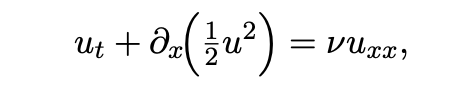

In [11]:
# Initial setup

N = 256
L = 2*np.pi
nu = 0.05
T = 0.9
N_t = 100
delta_t = T/N_t

def u_0(x):
    return np.sin(x) + (0.5)*np.sin(2*x) - (0.3)*np.cos(3*x)

# Sampling + FFT 
x_j = np.arange(N) * (L/N)
sampled_array = u_0(x_j)

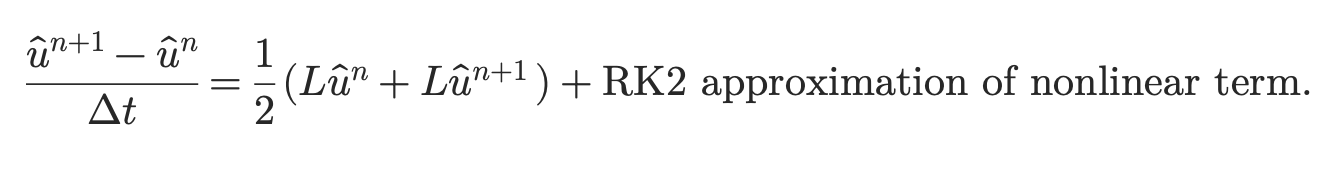

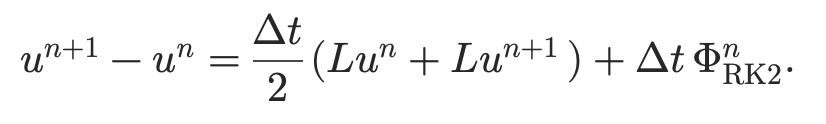

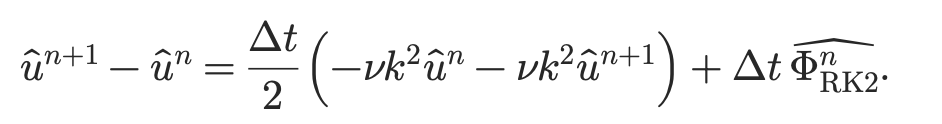

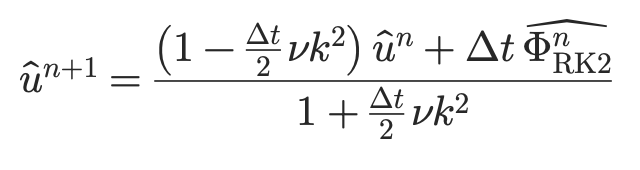

In [4]:
# Pseudospectral setup - dealiased run
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
k_max = np.max(np.abs(k_n))
mask = np.abs(k_n) > (2/3)*k_max

# Step 01: Spectral derivatives (spatial discreatization)
def spec_01(u):
    fft_u = np.fft.fft(0.5 * u**2)
    fft_u[mask] = 0
    return 1j * k_n * fft_u

def spec_02(u):
    return - nu * k_n**2 * np.fft.fft(u)

# Two variables:
# 1) u_n_time_step in physical space
# 2) u_hat_n_time_step in Fourier space

u_hat_n_time_step = np.fft.fft(u_0(x_j))
u_n_time_step = np.fft.ifft(u_hat_n_time_step)

for n in range(0,N_t):

    # RK2 (Heun's method)
    k_1 = -delta_t * np.fft.ifft(spec_01(u_n_time_step))
    k_2 = -delta_t * np.fft.ifft(spec_01(u_n_time_step + k_1))

    # Step 02: Time discretization (CN for the linear part, RK2 for the non-linear part)
    u_hat_n_plus_1_time_step = (u_hat_n_time_step * (1 - 0.5 * delta_t * nu * k_n**2) + np.fft.fft((1/2)*(k_1 + k_2)))/(1 + 0.5 * delta_t * nu * k_n**2)

    u_hat_n_time_step = u_hat_n_plus_1_time_step
    u_n_time_step = np.fft.ifft(u_hat_n_plus_1_time_step).real


In [5]:
# Pseudospectral setup - non-dealiased run
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)

# Step 01: Spectral derivatives (spatial discreatization)
def spec_01_non(u):
    fft_u = np.fft.fft(0.5 * u**2)
    return 1j * k_n * fft_u

def spec_02(u):
    return - nu * k_n**2 * np.fft.fft(u)

# Two variables:
# 1) u_hat_n_time_step_non in Fourier space
# 2) u_n_time_step_non in physical space

u_hat_n_time_step_non = np.fft.fft(u_0(x_j))
u_n_time_step_non = np.fft.ifft(u_hat_n_time_step_non)

for n in range(0,N_t):

    # RK2 (Heun's method)
    k_1 = -delta_t * np.fft.ifft(spec_01_non(u_n_time_step_non))
    k_2 = -delta_t * np.fft.ifft(spec_01_non(u_n_time_step_non + k_1))

    # Step 02: Time discretization (CN for the linear part, RK2 for the non-linear part)
    u_hat_n_plus_1_time_step_non = (u_hat_n_time_step_non * (1 - 0.5 * delta_t * nu * k_n**2) + np.fft.fft((1/2)*(k_1 + k_2)))/(1 + 0.5 * delta_t * nu * k_n**2)

    u_hat_n_time_step_non = u_hat_n_plus_1_time_step_non
    u_n_time_step_non = np.fft.ifft(u_hat_n_plus_1_time_step_non).real


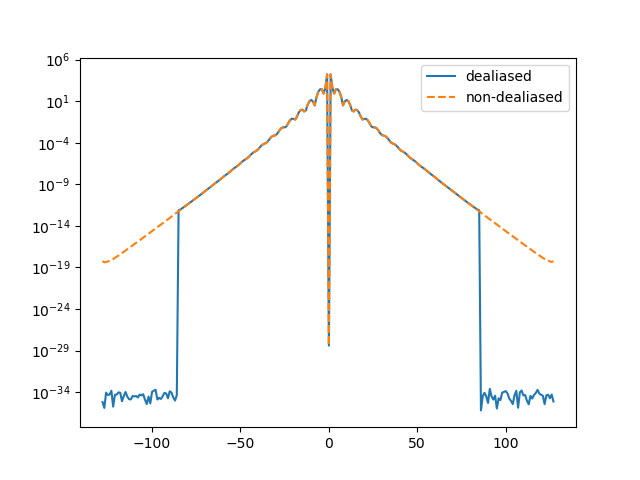

In [6]:
k_plot = np.fft.fftshift(k_n)
E_dealiased = np.fft.fftshift(np.abs(u_hat_n_time_step)**2)
E_non_dealiased = np.fft.fftshift(np.abs(u_hat_n_time_step_non)**2)

plt.semilogy(k_plot, E_dealiased, label="dealiased")
plt.semilogy(k_plot, E_non_dealiased, '--', label="non-dealiased")
plt.legend()
plt.show()

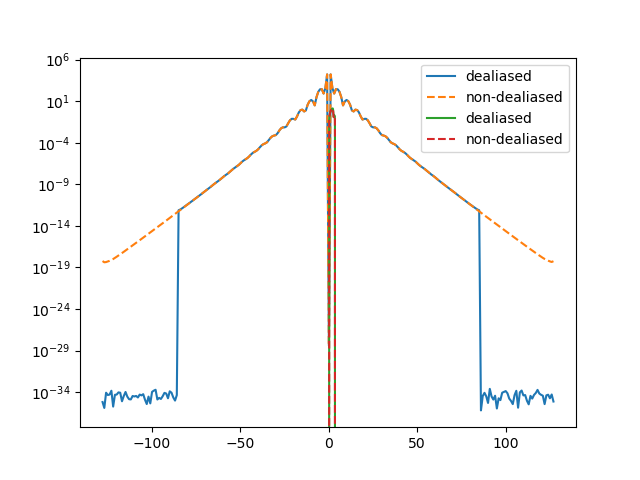

In [7]:
plt.semilogy(x_j, u_n_time_step, label="dealiased")
plt.semilogy(x_j, u_n_time_step_non, '--', label="non-dealiased")
plt.legend()
plt.show()

In [27]:
# Initial setup

resolutions = [64, 128, 256, 512]

L = 2*np.pi
nu = 0.05
T = 0.9
N_t = 100


u_N_dict = dict()

def u_0(x):
    return np.sin(x) + (0.5)*np.sin(2*x) - (0.3)*np.cos(3*x)

# Step 01: Spectral derivatives (spatial discreatization)
def spec_01(u):
    fft_u = np.fft.fft(0.5 * u**2)
    fft_u[mask] = 0
    return 1j * k_n * fft_u

def spec_02(u):
    return - nu * k_n**2 * np.fft.fft(u)

for N in resolutions:
    # Sampling + FFT 
    x_j = np.arange(N) * (L/N)
    sampled_array = u_0(x_j)

    # Pseudospectral setup - dealiased run
    k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
    k_max = np.max(np.abs(k_n))
    mask = np.abs(k_n) > (2/3)*k_max

    # Two variables:
    # 1) u_n_time_step in physical space
    # 2) u_hat_n_time_step in Fourier space

    delta_t = 1/N**2

    u_hat_n_time_step = np.fft.fft(u_0(x_j))
    u_n_time_step = np.fft.ifft(u_hat_n_time_step)

    for n in range(0,N_t):

        # RK2 (Heun's method)
        k_1 = -delta_t * np.fft.ifft(spec_01(u_n_time_step))
        k_2 = -delta_t * np.fft.ifft(spec_01(u_n_time_step + k_1))

        # Step 02: Time discretization (CN for the linear part, RK2 for the non-linear part)
        u_hat_n_plus_1_time_step = (u_hat_n_time_step * (1 - 0.5 * delta_t * nu * k_n**2) + np.fft.fft((1/2)*(k_1 + k_2)))/(1 + 0.5 * delta_t * nu * k_n**2)

        u_hat_n_time_step = u_hat_n_plus_1_time_step
        u_n_time_step = np.fft.ifft(u_hat_n_plus_1_time_step).real
    
    u_N_dict[N] = u_n_time_step


In [ ]:
u_ref = u_N_dict[512]
u_interpolated = dict()
summary_table = pd.DataFrame(columns = ['pair','error_l2','error_inf'])
error_coarser_grid = dict()
error_coarser_grid_l2 = dict()
error_coarser_grid_inf = dict()

# Interpolation of u_512 to a coarser grid
for N in [64, 128, 256]:
    x_j = np.arange(N) * (L/N)
    u_interpolated[N] = np.interp(x_j, np.arange(512) * (L/512), u_ref)


for (N_1, N_2) in [(64, 128), (128, 256), (256, 512)]:
    x_j = np.arange(N_1) * (L/N_1)
    error = u_N_dict[N_1] - np.interp(x_j, np.arange(N_2) * (L/N_2), u_N_dict[N_2])
    error_coarser_grid_l2 = np.sqrt( (1/N_1) * np.sum(np.abs(error)**2))
    error_coarser_grid_inf = la.linalg.norm(error, np.inf)

    summary_table.loc[len(summary_table)] = [(N_1,N_2),error_coarser_grid_l2,error_coarser_grid_inf]

summary_table

,pair,error_l2,error_inf
0,"(64, 128)",0.016482,0.043105
1,"(128, 256)",0.004156,0.011108
2,"(256, 512)",0.001041,0.002799


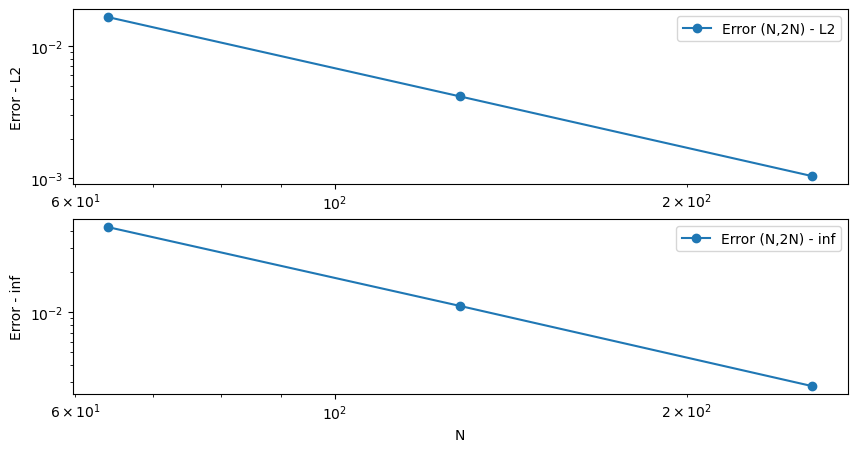

In [35]:
N_pairs = [64, 128, 256]
fig, ax = plt.subplots(nrows = 2,ncols = 1,
                      figsize =(10, 5))

ax[0].loglog(N_pairs, summary_table['error_l2'], marker="o", label="Error (N,2N) - L2")
ax[0].set_xlabel("N")
ax[0].set_ylabel("Error - L2")
ax[0].legend()

ax[1].loglog(N_pairs, summary_table['error_inf'], marker="o", label="Error (N,2N) - inf")
ax[1].set_xlabel("N")
ax[1].set_ylabel("Error - inf")
ax[1].legend()

plt.show()